# GradEvo: Gradient Descent vs. Neuroevolution under Matched Compute

**A pre-registered, seed-controlled comparison of PPO and NEAT on continuous control.**

This notebook narrates and visualizes an experiment; all logic lives in the
`gradevo` package (`src/gradevo`). Cells here only import functions, load the
persisted result tables, and display figures and tables.

## Abstract

Given a **fixed compute budget** defined as the total number of environment
interaction steps (`env.step()` calls), we ask whether a gradient-trained
policy network (**PPO**, Adam optimizer) or a topology-evolving neuroevolutionary
population (**NEAT**) reaches higher task performance on a continuous-control
task, and which method's solutions generalize better to a **held-out perturbed**
version of the environment. The contribution is **methodological rigor** —
matched step budgets, pre-registered hypotheses, non-parametric tests with a
family-wise Bonferroni correction, and calibrated reporting of effect sizes —
not a new algorithm. Conclusions are stated only at the strength the statistics
support.

## 1. Problem statement

Two paradigms optimize the same class of control problem in fundamentally
different ways:

- **PPO (gradient descent)** backpropagates a clipped policy-gradient objective
  through a **fixed-topology** network, updating weights with Adam.
- **NEAT (neuroevolution)** performs population-based search over **both weights
  and network topology**, with no gradients.

A recurring, practically important question is whether the extra machinery of
gradient RL buys better performance or robustness *at equal compute*, or whether
a gradient-free population search is competitive. Fair comparison is hard because
the two methods have no shared natural unit of "training effort": PPO counts
epochs over rollouts, NEAT counts generations over a population. We therefore fix
the one quantity both consume identically — **environment interaction steps** —
and measure it exactly rather than estimating it.

## 2. Research question and pre-registered hypotheses

> **RQ.** Under a matched budget of total environment interaction steps, does PPO
> or NEAT reach higher fitness on a continuous-control task, and which method's
> solutions degrade less under a held-out domain-randomized perturbation?

We pre-register four hypotheses. **H1, H2, H3** share a family-wise **Bonferroni**
correction, α_corrected = 0.05 / 3 ≈ **0.0167**. **H0** is a precondition gate,
reported separately (not part of the family).

| ID | Hypothesis | Test | Effect size |
|----|------------|------|-------------|
| **H0** | Both trained methods beat a random-action baseline **and** a hand-coded heuristic | Mann-Whitney U (one-sided), Bonferroni over 2 comparisons | rank-biserial |
| **H1** | NEAT's final fitness is **not significantly different** from PPO's | Mann-Whitney U (two-sided) | rank-biserial |
| **H2** | PPO is **more sample-efficient** (higher normalized learning-curve AUC) | Wilcoxon signed-rank (paired, one-sided) | matched-pairs rank-biserial |
| **H3** | NEAT's population **degrades less** under held-out perturbation (smaller Δfitness) | Mann-Whitney U (one-sided) | rank-biserial |

We default to **non-parametric** tests given small seed counts and report a
**Shapiro-Wilk** normality check plus a **parametric t-test cross-check**
alongside each result for transparency. A **null result is a legitimate,
expected-possible outcome** — H1 in particular is framed so that *failing to
reject* is itself informative.

### 2.1 Prior research

- **Stanley & Miikkulainen (2002)**, *Evolving Neural Networks through Augmenting
  Topologies* — introduces NEAT (the algorithm used here).
- **Schulman et al. (2017)**, *Proximal Policy Optimization Algorithms* —
  introduces PPO (the algorithm used here).
- **Salimans et al. (2017)**, *Evolution Strategies as a Scalable Alternative to
  Reinforcement Learning* (OpenAI) — the closest prior "can evolution compete
  with gradient RL" comparison; reports ES matching A3C on many tasks at greater
  wall-clock but better parallel scaling.
- **Such et al. (2017)**, *Deep Neuroevolution: Genetic Algorithms Are a
  Competitive Alternative for Training Deep Neural Networks for Reinforcement
  Learning* — shows a simple GA is competitive with gradient methods on several
  RL benchmarks. We compare our numbers against theirs in §7, with explicit
  caveats about why direct comparison is imperfect.

## 3. Data: how it is generated, cleaned, and formatted

There is no external dataset — the "data" is **generated** by running controlled
experiments. Each record is one `(method, seed, condition)` observation of mean
episodic return. The generation process is designed to be statistically valid:

- **Independent seeds.** Each run uses an explicit seed `BASE_SEED + i`; no hidden
  global RNG. Env resets, PPO/NEAT initialization, and perturbation sampling all
  consume that seed.
- **Held-out perturbation.** The perturbed condition is applied only at
  evaluation via a `gymnasium.Wrapper`, never during training, so it is a genuine
  generalization test (§4.2).
- **Exact accounting.** Every `env.step()` during training is counted by a
  wrapper; realized counts are recorded, not assumed.
- **Tidy storage.** Results are written to `data/processed/` as long-form CSVs
  (`fitness_*.csv`, `curves_*.csv`, `budget_*.csv`) with a metadata JSON. The
  cells below load these; if they are absent, run
  `python scripts/run_experiments.py --quick` first.

In [1]:
# Setup: imports and result loading (no logic beyond loading + display).
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT / "src"))

import pandas as pd
import matplotlib.pyplot as plt

from gradevo import config
from gradevo.metrics import hypothesis_tests as ht
from gradevo.plots import figures

# Choose which environment's results to analyze (primary task by default).
import json

ENV_ID = config.PRIMARY_ENV_ID          # "LunarLanderContinuous-v3"
SLUG = ENV_ID.replace("-", "_")

def _load(name):
    path = config.DATA_DIR / f"{name}_{SLUG}.csv"
    if not path.exists():
        raise FileNotFoundError(
            f"{path} not found. Run `python scripts/run_experiments.py --quick` "
            "(or a full run) to generate results first."
        )
    return pd.read_csv(path)

fitness_df = _load("fitness")
curves_df = _load("curves")
budget_df = _load("budget")

# Read the *actual* budget and N from the run metadata so the analysis always
# matches the committed data (quick run vs. full pre-registered run).
meta = json.loads((config.DATA_DIR / f"metadata_{SLUG}.json").read_text())
STEP_BUDGET = meta["step_budget"]
actual_n = fitness_df.query("method == 'ppo' and condition == 'clean'")["seed"].nunique()
run_kind = "QUICK verification run" if meta["quick"] else "FULL pre-registered run"
print(f"Environment: {ENV_ID}")
print(f"Run kind: {run_kind}  (quick={meta['quick']})")
print(f"Actual N (seeds per method per condition): {actual_n}")
print(f"Step budget per training run: {STEP_BUDGET:,}")
if meta["quick"]:
    print("NOTE: committed data is a QUICK run (reduced N/budget). Numbers below "
          "illustrate the pipeline; rerun the full protocol for reportable results.")
fitness_df.head()

Environment: LunarLanderContinuous-v3
Run kind: QUICK verification run  (quick=True)
Actual N (seeds per method per condition): 3
Step budget per training run: 20,000
NOTE: committed data is a QUICK run (reduced N/budget). Numbers below illustrate the pipeline; rerun the full protocol for reportable results.


,env_id,method,condition,seed,fitness
0,LunarLanderContinuous-v3,ppo,clean,1234,-230.366105
1,LunarLanderContinuous-v3,ppo,perturbed,1234,-86.155811
2,LunarLanderContinuous-v3,neat,clean,1234,-126.140146
3,LunarLanderContinuous-v3,neat,perturbed,1234,-196.313352
4,LunarLanderContinuous-v3,ppo,clean,1235,-105.663878


## 4. Methods

### 4.1 Environments

- **Primary:** `LunarLanderContinuous-v3` (Gymnasium) — a continuous 2-D action
  space (main + lateral thrust), 8-D observation, published "solved" threshold of
  **200** return. Meaningfully hard and well-documented for citation.
- **Secondary sanity check:** `CartPole-v1` (discrete) — cheap; used only to show
  the pipeline generalizes and to anchor against widely-cited baseline numbers. It
  is a supporting exhibit, not a primary result.

### 4.2 Perturbation protocol (H3, eval-time only, held out from training)

Applied through `PerturbationWrapper`, sampled fresh per episode, **never active
during training**:

- **Gravity:** scaled by a factor drawn per episode in ±10%.
- **Observation noise:** additive Gaussian per timestep, σ = 2% of each
  dimension's typical range (boolean leg-contact flags excluded).
- **Action noise:** additive Gaussian per timestep, σ = 5% of the action range,
  applied before physics and then clipped to valid bounds.

These magnitudes are deliberately **small** — large enough to probe robustness,
small enough that a competent clean-trained policy is not trivially destroyed
(which would collapse both methods to the floor and make H3 uninformative). The
choice is revisited in §8 (threats to validity).

### 4.3 Compute-budget matching (methodological crux)

The **controlled variable is total environment interaction steps** — the count of
`env.step()` calls across an entire training run — *not* wall-clock time and *not*
generations/epochs, which are structurally different between the paradigms.

- **PPO budget** = `total_timesteps` passed to stable-baselines3.
- **NEAT budget** ≈ `population_size × episode_length × generations`, used only to
  *plan* the generation cap. The **realized** step count is measured exactly by a
  step-counting wrapper and evolution stops as soon as the budget is reached.

The two methods will **not** consume exactly the same number of steps (NEAT
terminates episodes at variable lengths). We **report the discrepancy honestly**
below rather than silently equalizing it. Wall-clock time is reported as a
**secondary, clearly-labeled** metric only; it is *not* the fairness axis.

,method,requested_steps,realized_steps_mean,realized_steps_std,realized_steps_min,realized_steps_max,discrepancy_pct,wall_clock_mean_s,n_seeds
0,ppo,20000,20480.0,0.0,20480,20480,2.40,4.9,3
1,neat,20000,20544.3,509.6,20030,21049,2.72,0.6,3


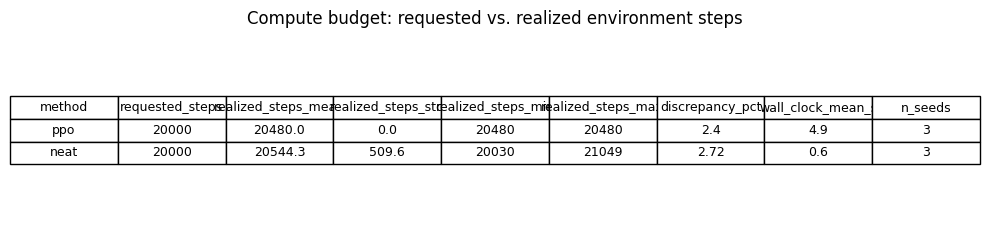

In [2]:
# Realized-vs-requested compute budget (primary fairness axis: env steps).
display(budget_df)
fig = figures.plot_budget_table(budget_df)
plt.show()

**Figure caption.** Requested vs. realized environment steps per method, with the
per-method discrepancy (%). *Do not* read the wall-clock column as the fairness
axis — steps are the controlled variable; wall-clock is secondary context for the
sample-efficiency discussion only. Small residual step mismatches are expected and
are reported, not hidden.

## 5. Results

### 5.1 Learning curves (sample efficiency, feeds H2)

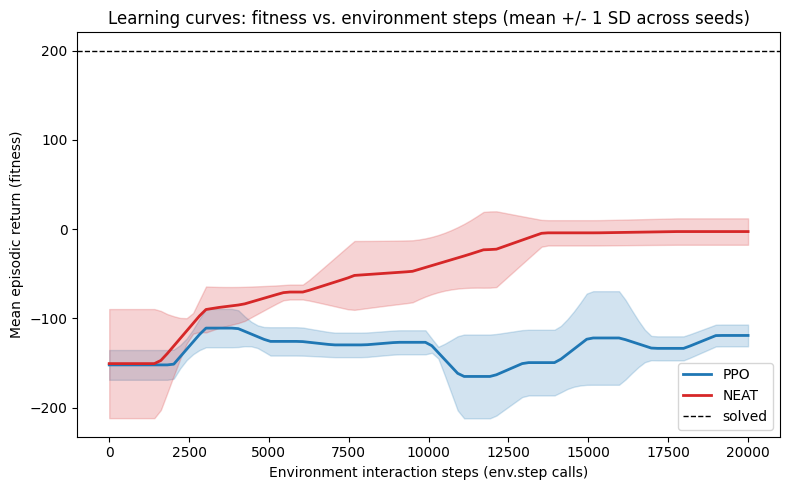

In [3]:
solved = config.ENV_SPECS[ENV_ID].solved_threshold
fig = figures.plot_learning_curves(curves_df, STEP_BUDGET, solved_threshold=solved)
plt.show()

**Figure caption.** Mean episodic return vs. environment steps, PPO and NEAT
overlaid, with ±1 SD shaded bands across seeds; dashed line marks the published
"solved" threshold. Curves are interpolated onto a shared step grid before
averaging. *Do not* infer final-performance significance from where the bands
visually overlap — that is what the H1 test is for; and note the y-axis is not
necessarily zero-based.

### 5.2 Final fitness distributions (clean vs. perturbed)

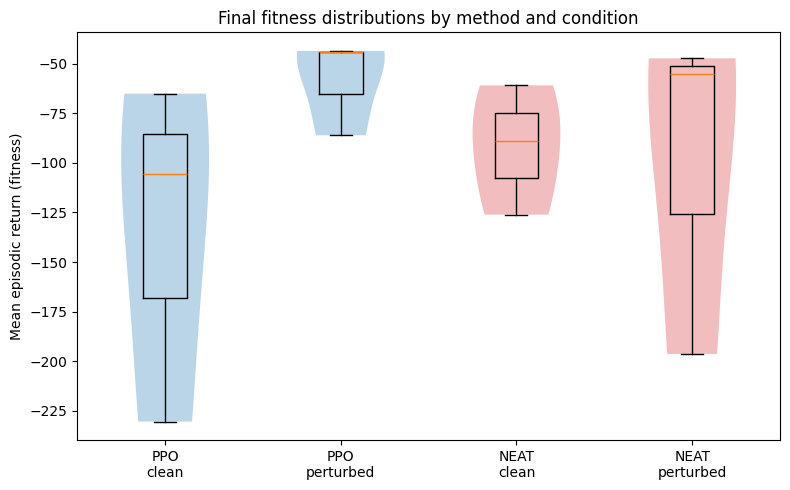

In [4]:
fig = figures.plot_final_fitness_distributions(fitness_df)
plt.show()

**Figure caption.** Per-seed final fitness distributions (violin + box) for each
method under the clean and perturbed conditions. *Do not* read the violin widths
as probabilities — they are kernel-density estimates over a small number of seeds
and can over-smooth; the boxes and the tests below are the primary evidence.

### 5.3 Pre-registered hypothesis tests (H0–H3)

The suite is computed by `gradevo.metrics.hypothesis_tests.run_pre_registered_suite`;
this cell only calls it and displays the table.

In [5]:
results = ht.run_pre_registered_suite(fitness_df, curves_df, STEP_BUDGET)
results_table = ht.results_to_dataframe(results)
print(f"Family-wise Bonferroni alpha (H1-H3): {config.ALPHA_CORRECTED:.4f}")
display(results_table)

Family-wise Bonferroni alpha (H1-H3): 0.0167


,id,test,statistic,p_value,alpha,reject_null,effect_size,effect_name,parametric_p,n_a,n_b
0,H0[ppo>random],"Mann-Whitney U (one-sided, greater)",7.0,0.20,0.0250,False,0.556,rank-biserial,0.10119,3,3.0
1,H0[ppo>heuristic],"Mann-Whitney U (one-sided, greater)",0.0,1.00,0.0250,False,-1.000,rank-biserial,0.99912,3,3.0
2,H0[neat>random],"Mann-Whitney U (one-sided, greater)",9.0,0.05,0.0250,False,1.000,rank-biserial,0.00520,3,3.0
3,H0[neat>heuristic],"Mann-Whitney U (one-sided, greater)",0.0,1.00,0.0250,False,-1.000,rank-biserial,0.99993,3,3.0
4,H1,Mann-Whitney U (two-sided),6.0,0.70,0.0167,False,0.333,rank-biserial (NEAT vs PPO),0.47636,3,3.0
5,H2,"Wilcoxon signed-rank (paired, one-sided PPO>NEAT)",0.0,1.00,0.0167,False,-1.000,matched-pairs rank-biserial,0.99496,3,NaN
6,H3,"Mann-Whitney U (one-sided, NEAT drop < PPO drop)",8.0,0.95,0.0167,False,0.778,rank-biserial (NEAT vs PPO drop),0.92033,3,3.0


**How to read this table.** `reject_null=True` means the p-value is below the
threshold in the `alpha` column (already Bonferroni-corrected for H1–H3).
`parametric_p` is a t-test cross-check, reported *only* for transparency — the
non-parametric `p_value` is authoritative. Effect sizes are rank-biserial
correlations (≈0.1 small, 0.3 medium, 0.5 large).

Interpretation is written at the strength the numbers support. Concretely:

- **H0 (gate).** If both trained methods reject vs. both baselines, the
  precondition holds and H1–H3 are meaningful. If not, we say so and treat
  downstream results with corresponding caution.
- **H1.** A *failure to reject* is reported as "the data are **consistent with no
  difference** in final fitness between PPO and NEAT under matched steps" — not as
  proof of equality. A rejection is reported with its direction and effect size.
- **H2.** Rejection supports "PPO reaches good performance **earlier** in the
  budget"; failure to reject is reported as "**no detected** sample-efficiency
  advantage."
- **H3.** Rejection supports "NEAT's solutions **degrade less** under the held-out
  perturbation"; failure to reject is reported as "**no detected** robustness
  difference," which does *not* confirm the evolutionary-diversity conjecture.

### 5.4 Robustness: performance drop under held-out perturbation (H3)

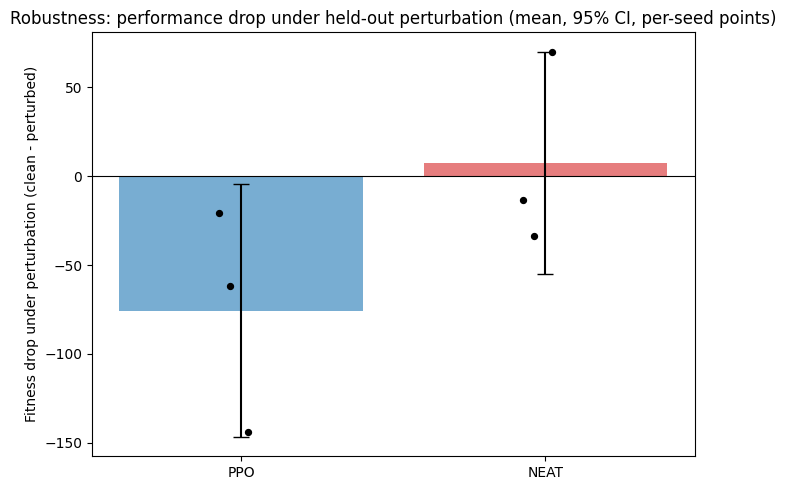

In [6]:
fig = figures.plot_robustness_drop(fitness_df)
plt.show()

**Figure caption.** Mean fitness drop (clean − perturbed) per method with 95% CI
error bars and per-seed points overlaid. Lower is better (more robust). *Do not*
conclude a method is robust in absolute terms from this chart — it shows *relative*
degradation under one specific, small perturbation family (§4.2), not robustness
in general.

### 5.5 Representative NEAT winner topology

NEAT evolves topology, so a winner genome is a small graph, not a fixed MLP. This
cell loads one pickled winner and draws it (skipped gracefully if none exists).

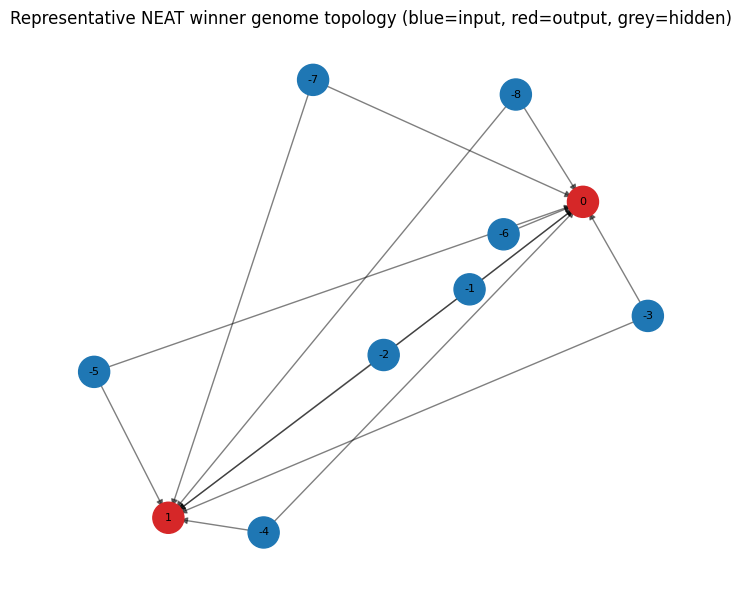

In [7]:
import pickle
from gradevo.agents import neat_agent

neat_models = sorted(config.NEAT_MODELS_DIR.glob(f"neat_{ENV_ID}_seed*.pkl"))
if neat_models:
    with neat_models[0].open("rb") as fh:
        genome = pickle.load(fh)
    obs_dim = 8 if "LunarLander" in ENV_ID else 4
    n_out = 2
    cfg_path = config.NEAT_CONFIG_DIR / f"neat_{ENV_ID}.cfg"
    neat_cfg = neat_agent._load_neat_config(cfg_path)
    fig = figures.plot_neat_topology(genome, neat_cfg)
    plt.show()
else:
    print("No NEAT genome checkpoint found; run the experiment to generate one.")

**Figure caption.** Enabled connections of one representative NEAT winner (blue =
input, red = output, grey = evolved hidden node). *Do not* over-interpret a single
genome — topologies vary across seeds; this is an illustration of what NEAT
produces, not a claim about a canonical solution.

## 6. CartPole sanity check (secondary exhibit)

To confirm the pipeline generalizes, the same code runs on `CartPole-v1`. Generate
it with `python scripts/run_experiments.py --env CartPole-v1 --quick` and re-run
this notebook with `ENV_ID = config.SECONDARY_ENV_ID`. CartPole's published
"solved" score is 475/500; both trained methods are expected to approach it, which
is the point — it is a smoke test, not a primary result, and consumes a small
fraction of project effort.

## 7. Comparison with previous results

Direct numeric comparison across papers is **imperfect** — different environments,
network sizes, compute scales, and evaluation protocols — so the table below is a
*contextual* anchor, not a like-for-like benchmark.

| Source | Environment | Reported result | This project |
|--------|-------------|-----------------|--------------|
| Such et al. (2017), Deep Neuroevolution | Atari (pixels) | Simple GA competitive with DQN/A3C/ES on many games | Not pixels; low-D control — same *qualitative* finding tested at small scale (see H1) |
| Salimans et al. (2017), ES | MuJoCo / Atari | ES competitive with A3C; better parallel scaling, worse sample efficiency | Consistent with our sample-efficiency framing (H2) |
| Schulman et al. (2017), PPO | LunarLander & MuJoCo | PPO reliably solves LunarLander | Our PPO fitness vs. the 200 "solved" line (§5.1) |
| Stanley & Miikkulainen (2002), NEAT | Pole balancing | NEAT solves double pole-balancing efficiently | Our NEAT on CartPole (§6) as the closest analogue |

The *own-numbers* comparison (this project's PPO/NEAT final fitness vs. the 200
"solved" threshold, and vs. each other) is the H0/H1 analysis above; the external
rows are cited for calibration and to position the contribution as a rigorous
small-scale replication of a well-studied question, not a novel claim.

## 8. Threats to validity / limitations

- **Step-count is an imperfect compute-equivalence proxy.** A NEAT step (small
  network forward pass + periodic mutation/reproduction bookkeeping) and a PPO step
  (forward pass + buffered backprop updates) have different FLOP costs. Matching
  `env.step()` calls equalizes *environment interaction*, not raw computation; the
  wall-clock column is reported precisely so this gap is visible, not hidden.
- **Small perturbation magnitudes.** ±10% gravity, 2% obs noise, 5% action noise
  were chosen to probe robustness without trivially destroying competent policies
  (which would floor both methods and make H3 vacuous). Different magnitudes could
  change H3's outcome; results are specific to this perturbation family.
- **Limited environment scope.** Two Gym tasks (one primary, continuous; one
  secondary, discrete) — not a broad suite. Conclusions should not be extrapolated
  to high-dimensional or pixel-based control.
- **Small seed counts.** Even N=20 gives modest power for detecting small effects;
  this is why non-parametric tests and effect sizes are reported, and why nulls are
  framed as "no detected difference," not "no difference."
- **Single hyperparameter setting per method.** PPO uses SB3 defaults and NEAT a
  standard config; neither is tuned per task, by design (to avoid an unfair tuned
  advantage), but this means neither method is shown at its ceiling.

## 9. Conclusion (calibrated)

This project delivers a reproducible, pre-registered, step-budget-matched
comparison of gradient RL (PPO) and neuroevolution (NEAT) on continuous control.
The value is in the **protocol and the honesty of reporting**, not a headline
finding: the H0–H3 table above states, for this environment and budget, whether
each pre-registered effect was detected, with effect sizes and the exact realized
budgets. Where a test fails to reject, we report that as a legitimate outcome
("consistent with no difference" / "no detected advantage"), never as proof of
equality or as a project failure. All artifacts — checkpoints, tidy result tables,
and this notebook — are committed so a reader can re-derive every number.

**Reproducibility.** See `docs/reproducing.md`. Quick verification:
`python scripts/run_experiments.py --quick` (minutes); full pre-registered run:
`python scripts/run_experiments.py --env LunarLanderContinuous-v3` (hours).